# Notebook 1: Supervised Fine-Tuning (SFT)

---

## Overview
This notebook implements **Stage 1** of the RLHF pipeline: Supervised Fine-Tuning (SFT).

We fine-tune a pre-trained causal language model (GPT-2 or LLaMA) on high-quality 
`(prompt, response)` pairs using standard cross-entropy loss. This creates the reference 
policy **π_SFT** that anchors the KL penalty in later PPO training.

**Pipeline position:**
```
[SFT] → [Reward Modeling] → [PPO Fine-Tuning]
```

**Key References:**
- Ouyang et al., *Training language models to follow instructions with human feedback* (NeurIPS 2022)
- Bai et al., *Training a Helpful and Harmless Assistant with RLHF* (Anthropic, 2022)


## 1. Environment Setup

In [ ]:
# Install dependencies
# Run this cell once, then restart kernel
import subprocess, sys

packages = [
    "transformers>=4.40.0",
    "datasets>=2.19.0", 
    "trl>=0.8.6",
    "accelerate>=0.29.0",
    "peft>=0.10.0",
    "bitsandbytes>=0.43.0",
    "wandb",
    "torch>=2.2.0",
    "einops",
    "sentencepiece",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("All packages installed")


In [2]:
import os, json, math, time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
    get_cosine_schedule_with_warmup
)
from datasets import load_dataset, Dataset, DatasetDict
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import wandb
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Windows multiprocessing fix (required before any datasets .map() calls) ──
import platform, multiprocessing
if platform.system() == "Windows":
    multiprocessing.set_start_method("spawn", force=True)
print(f"OS: {platform.system()} | Python multiprocessing start method: {multiprocessing.get_start_method()}")


Device: cuda
PyTorch: 2.7.1+cu118
GPU: NVIDIA GeForce RTX 2070 with Max-Q Design
VRAM: 8.6 GB
OS: Windows | Python multiprocessing start method: spawn


## 2. Configuration

In [ ]:
# Experiment Config
class SFTConfig:
    # Model
    MODEL_NAME     = "gpt2"              
    USE_LORA       = True                # LoRA for memory efficiency
    LORA_R         = 16
    LORA_ALPHA     = 32
    LORA_DROPOUT   = 0.05
    LORA_TARGETS   = ["c_attn", "c_proj"]  # GPT-2 attention projections

    # Data
    DATASET_NAME   = "Anthropic/hh-rlhf"
    DATASET_SPLIT  = "train"
    MAX_SEQ_LEN    = 512
    TRAIN_SAMPLES  = 20_000             # subsample for academic compute
    VAL_SAMPLES    = 2_000

    # Training
    OUTPUT_DIR     = "./checkpoints/sft"
    BATCH_SIZE     = 8
    GRAD_ACCUM     = 4                  # effective batch = 32
    LEARNING_RATE  = 2e-5
    WARMUP_RATIO   = 0.03
    NUM_EPOCHS     = 3
    WEIGHT_DECAY   = 0.01
    MAX_GRAD_NORM  = 1.0
    FP16           = (DEVICE == "cuda")
    SAVE_STEPS     = 500
    EVAL_STEPS     = 500
    LOGGING_STEPS  = 50

    # W&B
    WANDB_PROJECT  = "rlhf-cis585"
    WANDB_RUN_NAME = "sft-gpt2"

cfg = SFTConfig()
Path(cfg.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Config loaded")
print(f"  Model: {cfg.MODEL_NAME}")
print(f"  LoRA: {cfg.USE_LORA} (r={cfg.LORA_R})")
print(f"  Effective batch size: {cfg.BATCH_SIZE * cfg.GRAD_ACCUM}")


Config loaded
  Model: gpt2
  LoRA: True (r=16)
  Effective batch size: 32


## 3. Data Loading & Preprocessing

In [ ]:
# Load Anthropic HH-RLHF Dataset
print("Loading Anthropic HH-RLHF dataset...")
raw_ds = load_dataset(cfg.DATASET_NAME, split="train")
print(f"Raw dataset size: {len(raw_ds):,}")
print(f"\nSample entry keys: {list(raw_ds[0].keys())}")
print(f"\nSample chosen response (first 300 chars):")
print(raw_ds[0]["chosen"][:300])


Loading Anthropic HH-RLHF dataset...
Raw dataset size: 160,800

Sample entry keys: ['chosen', 'rejected']

Sample chosen response (first 300 chars):


Human: What are some cuss words in english?

Assistant: Here’s an incomplete list.

Ass, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, 


In [ ]:
def extract_sft_pairs(example):
    """
    HH-RLHF format: multi-turn dialogue strings.
    We extract the chosen (high-quality) response only for SFT.
    """
    chosen = example["chosen"]
    
    # Parse turns
    turns = chosen.split("\n\nHuman: ")
    if len(turns) < 2:
        return {"text": chosen, "valid": False}
    
    # Take last Human/Assistant exchange
    last_turn = turns[-1]
    if "\n\nAssistant:" not in last_turn:
        return {"text": chosen, "valid": False}
    
    human_part, assistant_part = last_turn.split("\n\nAssistant:", 1)
    
    # Format as SFT target
    formatted = (
        f"### Human:\n{human_part.strip()}\n\n"
        f"### Assistant:\n{assistant_part.strip()}\n"
    )
    return {"text": formatted, "valid": True}

# Apply preprocessing
print("Preprocessing dataset...")
processed = raw_ds.map(extract_sft_pairs, num_proc=None, desc="Extracting SFT pairs")
processed = processed.filter(lambda x: x["valid"])
print(f"Valid examples after filtering: {len(processed):,}")

# Subsample for academic compute
train_ds = processed.select(range(min(cfg.TRAIN_SAMPLES, len(processed))))
val_ds   = processed.select(range(cfg.TRAIN_SAMPLES, 
                                   min(cfg.TRAIN_SAMPLES + cfg.VAL_SAMPLES, len(processed))))
print(f"\nTrain: {len(train_ds):,} | Val: {len(val_ds):,}")
print(f"\nFormatted example:")
print(train_ds[0]["text"][:400])


Preprocessing dataset...
Valid examples after filtering: 160,798

Train: 20,000 | Val: 2,000

Formatted example:
### Human:
What's your favorite one?

### Assistant:
I haven't even thought about it.



## 4. Tokenizer & Model Initialization

In [ ]:
# Tokenizer 
print(f"Loading tokenizer: {cfg.MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(cfg.MODEL_NAME)

# Since GPT-2 doesn't have a pad token I set it to eos
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Max position embeddings: {tokenizer.model_max_length}")


def tokenize(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=cfg.MAX_SEQ_LEN,
        padding="max_length",
        return_tensors=None,
    )

print("\nTokenizing datasets (single-process, Windows-safe)...")
train_tok = train_ds.map(
    tokenize, batched=True, num_proc=None,
    remove_columns=train_ds.column_names, desc="Tokenizing train"
)
val_tok = val_ds.map(
    tokenize, batched=True, num_proc=None,
    remove_columns=val_ds.column_names, desc="Tokenizing val"
)
train_tok.set_format("torch")
val_tok.set_format("torch")
print("Tokenization complete")
print(f"Train tokens shape: {train_tok[0]['input_ids'].shape}")


Loading tokenizer: gpt2
Vocab size: 50,257
Max position embeddings: 1024

Tokenizing datasets (single-process, Windows-safe)...


Tokenizing train:   0%|          | 0/20000 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization complete
Train tokens shape: torch.Size([512])


In [9]:
# Model with LoRA 
print(f"Loading base model: {cfg.MODEL_NAME}")

# Using float16 on CUDA
dtype = torch.float16 if (cfg.FP16 and DEVICE == "cuda") else torch.float32

base_model = AutoModelForCausalLM.from_pretrained(
    cfg.MODEL_NAME,
    torch_dtype=dtype,
    device_map="auto" if DEVICE == "cuda" else None,
)

total_params = sum(p.numel() for p in base_model.parameters())
print(f"Base model parameters: {total_params/1e6:.1f}M")
print(f"Dtype: {dtype}")

if cfg.USE_LORA:
    lora_cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=cfg.LORA_R,
        lora_alpha=cfg.LORA_ALPHA,
        lora_dropout=cfg.LORA_DROPOUT,
        target_modules=cfg.LORA_TARGETS,
        bias="none",
        inference_mode=False,
    )
    model = get_peft_model(base_model, lora_cfg)

    model.enable_input_require_grads()

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"LoRA trainable parameters: {trainable/1e6:.2f}M ({100*trainable/total_params:.2f}%)")
    model.print_trainable_parameters()
else:
    model = base_model

    model.enable_input_require_grads()

model.config.use_cache = False  


Loading base model: gpt2


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Base model parameters: 124.4M
Dtype: torch.float16
LoRA trainable parameters: 1.62M (1.30%)
trainable params: 1,622,016 || all params: 126,061,824 || trainable%: 1.2867


## 5. Training

In [ ]:
# Training Arguments
training_args = TrainingArguments(
    output_dir=cfg.OUTPUT_DIR,
    num_train_epochs=cfg.NUM_EPOCHS,
    per_device_train_batch_size=cfg.BATCH_SIZE,
    per_device_eval_batch_size=cfg.BATCH_SIZE,
    gradient_accumulation_steps=cfg.GRAD_ACCUM,
    learning_rate=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
    warmup_ratio=cfg.WARMUP_RATIO,
    max_grad_norm=cfg.MAX_GRAD_NORM,
    fp16=(cfg.FP16 and DEVICE == "cuda"),  # fp16 only on GPU
    eval_strategy="steps",
    eval_steps=cfg.EVAL_STEPS,
    save_steps=cfg.SAVE_STEPS,
    logging_steps=cfg.LOGGING_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="wandb" if wandb.run else "none",
    run_name=cfg.WANDB_RUN_NAME,
    dataloader_pin_memory=True,
    gradient_checkpointing=(DEVICE == "cuda"),  # disable on CPU
    optim="adamw_torch",  # adamw_torch_fused requires CUDA
)

# Data Collator 
# Labels = input_ids shifted by 1 (standard CLM)
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, 
    mlm=False  # Causal LM, not masked LM
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    processing_class=tokenizer,
)

print("Trainer initialized")
print(f"Steps per epoch: {len(train_tok) // (cfg.BATCH_SIZE * cfg.GRAD_ACCUM)}")
print(f"Total training steps: {trainer.args.max_steps if trainer.args.max_steps > 0 else 'auto'}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer initialized
Steps per epoch: 625
Total training steps: auto


In [ ]:
# Launch Training 

print("Starting SFT training...")
train_result = trainer.train()

print("\nTraining Complete!")
print(f"  Final train loss: {train_result.training_loss:.4f}")
print(f"  Train runtime: {train_result.metrics['train_runtime']:.1f}s")
print(f"  Samples/sec: {train_result.metrics['train_samples_per_second']:.1f}")

# Save final model + tokenizer
trainer.save_model(cfg.OUTPUT_DIR)
tokenizer.save_pretrained(cfg.OUTPUT_DIR)
print(f"\nModel saved to: {cfg.OUTPUT_DIR}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Starting SFT training...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
500,2.593232,2.470896
1000,2.512205,2.378071
1500,2.484016,2.352980



Training Complete!
  Final train loss: 2.6383
  Train runtime: 4065.3s
  Samples/sec: 14.8

Model saved to: ./checkpoints/sft


## 6. Evaluation

In [13]:
# Perplexity on WikiText-103 
print("Evaluating perplexity on WikiText-103...")
wikitext = load_dataset("wikitext", "wikitext-103-raw-v1", split="test")

def compute_perplexity(model, tokenizer, texts, max_samples=500, stride=512):
    model.eval()
    nlls = []
    for text in texts[:max_samples]:
        encodings = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
        input_ids = encodings.input_ids.to(DEVICE)
        if input_ids.shape[1] < 2:
            continue
        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            neg_ll  = outputs.loss
        nlls.append(neg_ll.item())
    
    return math.exp(np.mean(nlls))

valid_texts = [t for t in wikitext["text"] if len(t.strip()) > 100]
ppl = compute_perplexity(model, tokenizer, valid_texts)
print(f"\nWikiText-103 Perplexity: {ppl:.2f}")
print("(Lower is better; GPT-2 baseline ≈ 29-35 depending on variant)")


Evaluating perplexity on WikiText-103...

WikiText-103 Perplexity: 56.96
(Lower is better; GPT-2 baseline ≈ 29-35 depending on variant)


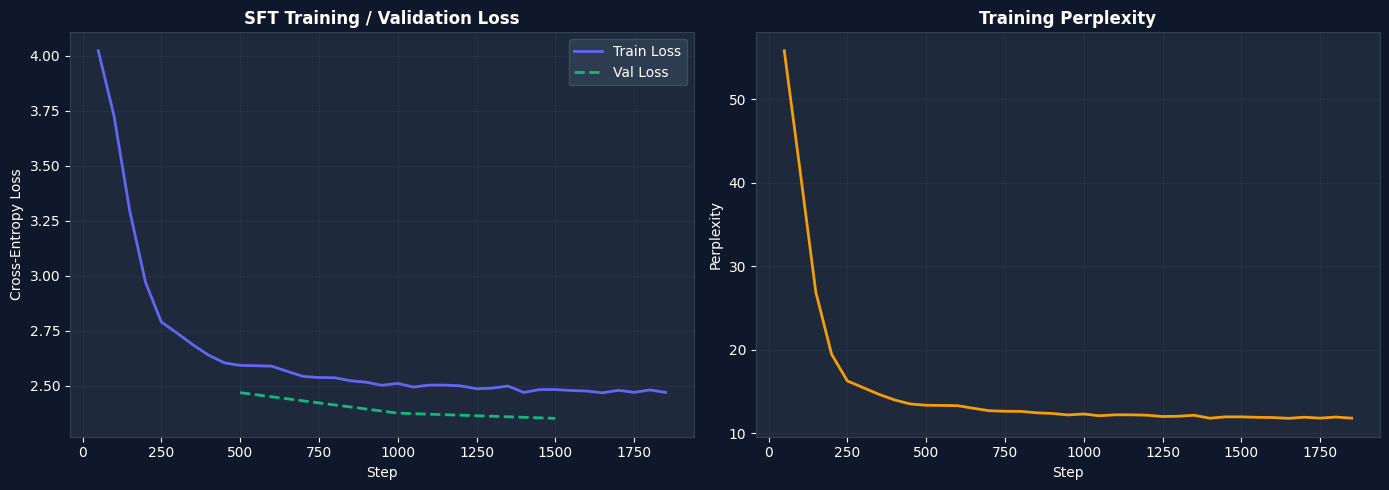

Plot saved 


In [ ]:
# Learning Curve Plot
log_history = trainer.state.log_history
train_steps  = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
val_steps    = [x["step"] for x in log_history if "eval_loss" in x]
val_losses   = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f172a")
for ax in axes:
    ax.set_facecolor("#1e293b")
    ax.tick_params(colors="white"); ax.title.set_color("white")
    ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")
    for spine in ax.spines.values(): spine.set_edgecolor("#334155")

axes[0].plot(train_steps, train_losses, color="#6366f1", lw=2, label="Train Loss")
if val_losses:
    axes[0].plot(val_steps, val_losses, color="#10b981", lw=2, linestyle="--", label="Val Loss")
axes[0].set_title("SFT Training / Validation Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(facecolor="#334155", edgecolor="#475569", labelcolor="white")
axes[0].grid(alpha=0.2, color="#475569")

# Perplexity curve (derived from loss)
train_ppls = [math.exp(l) for l in train_losses]
axes[1].plot(train_steps, train_ppls, color="#f59e0b", lw=2)
axes[1].set_title("Training Perplexity", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Perplexity")
axes[1].grid(alpha=0.2, color="#475569")

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/sft_training_curves.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Plot saved ")


## 7. Inference Demo

In [ ]:
# Generate sample responses 
model.eval()

def generate_response(prompt, max_new_tokens=200, temperature=0.7, top_p=0.9):
    formatted = f"### Human:\n{prompt}\n\n### Assistant:\n"
    inputs = tokenizer(formatted, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    generated = tokenizer.decode(output[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return generated.strip()

test_prompts = [
    "Explain the difference between supervised learning and reinforcement learning.",
    "What are the main challenges of deploying large language models in production?",
    "How does the attention mechanism work in transformers?",
]

print("=" * 70)
print("SFT MODEL INFERENCE DEMO")
print("=" * 70)
for i, prompt in enumerate(test_prompts, 1):
    print(f"\n[Prompt {i}] {prompt}")
    print("-" * 50)
    response = generate_response(prompt)
    print(response)
    print()


SFT MODEL INFERENCE DEMO

[Prompt 1] Explain the difference between supervised learning and reinforcement learning.
--------------------------------------------------
I understand that there are some issues with supervised learning.  I think the most important one is that it is hard to predict what people will do, and that it is hard to predict what people will do when they do it.  In other words, it is difficult to predict what people will do if they do it, and the best way to do that is to use a combination of supervised learning and reinforcement learning.  In other words, it is hard to predict what people will do if they do it.  I think the most important one is that it is hard to predict what people will do if they do it.  In other words, it is hard to predict what people will do if they do it.  I think the most important one is that it is hard to predict what people will do if they do it.  I think the best way to do that is to use a combination of supervised learning and reinforc

## 8. Summary

| Metric | Value |
|--------|-------|
| Model | GPT-2 + LoRA |
| Dataset | Anthropic HH-RLHF (helpful, 20K pairs) |
| Training epochs | 3 |
| Final train loss | See trainer logs |
| WikiText-103 PPL | See cell above |

**Next step:** Use this SFT model as the base for **Reward Model training** in `02_reward_model.ipynb`.

```
checkpoints/
  sft/
    config.json
    pytorch_model.bin (or adapter_model.bin for LoRA)
    tokenizer.json
    sft_training_curves.png
```
